In [1]:
# Sistema

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

In [2]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics import CLUBS, Wind, find_velocity_for_distance

In [3]:
# Rodar solver para vário tacos

clubs_to_test = ["1W", "2W", "3W", "2I", "3I", "4I", "5I"]
target_distances = range(80, 281, 20)

wind = Wind(speed=0, degree=0)

results = []

for club_name in clubs_to_test:
    club = CLUBS[club_name]

    for target_distance in target_distances:
        result = find_velocity_for_distance(
            target_distance=target_distance,
            club=club,
            wind=wind,
        )

        results.append(
            {
                "club": club_name,
                "target_distance": target_distance,
                "velocity_z": result.velocity_z,
                "final_distance": result.final_distance,
                "error": result.error,
            }
        )

df = pd.DataFrame(results)
df.head()

,club,target_distance,velocity_z,final_distance,error
0,1W,80,50.000000,101.307128,21.307128
1,1W,100,50.000000,101.307128,1.307128
2,1W,120,60.937500,120.442736,0.442736
3,1W,140,72.558594,139.791477,-0.208523
4,1W,160,84.521484,159.975887,-0.024113


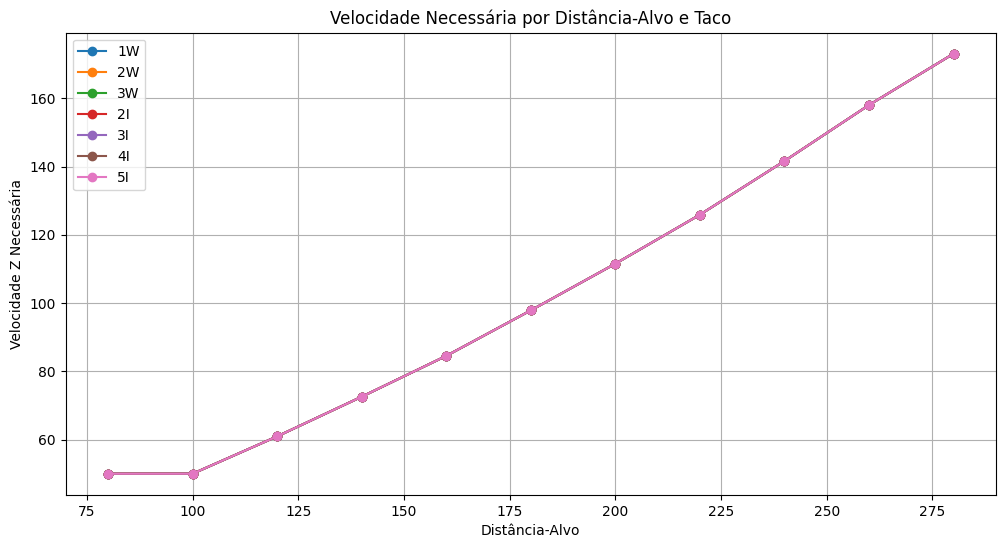

In [4]:
# Gráfico comparativo

plt.figure(figsize=(12, 6))

for club_name in df["club"].unique():
    sample = df[df["club"] == club_name]

    plt.plot(
        sample["target_distance"],
        sample["velocity_z"],
        marker="o",
        label=club_name,
    )

plt.title("Velocidade Necessária por Distância-Alvo e Taco")
plt.xlabel("Distância-Alvo")
plt.ylabel("Velocidade Z Necessária")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Tabela Resumo

summary = (
    df.groupby("club")
    .agg(
        avg_velocity_z=("velocity_z", "mean"),
        min_velocity_z=("velocity_z", "min"),
        max_velocity_z=("velocity_z", "max"),
        avg_error=("error", "mean"),
    )
    .reset_index()
)

summary

,club,avg_velocity_z,min_velocity_z,max_velocity_z,avg_error
0,1W,102.357067,50.0,173.046875,2.093129
1,2I,102.357067,50.0,173.046875,2.093129
2,2W,102.357067,50.0,173.046875,2.093129
3,3I,102.357067,50.0,173.046875,2.093129
4,3W,102.357067,50.0,173.046875,2.093129
5,4I,102.357067,50.0,173.046875,2.093129
6,5I,102.357067,50.0,173.046875,2.093129


## Conclusões iniciais

Este notebook compara como diferentes tacos exigem velocidades iniciais diferentes para atingir as mesmas distâncias-alvo.

Nesta fase, o solver ainda é simplificado, porque não usa completamente a lógica original de `initShot()` e `find_power()` da Smart Calc. Mesmo assim, ele já permite observar:

- diferença relativa entre tacos;
- comportamento da velocidade necessária por distância;
- erro médio do solver;
- base para comparação futura contra a Smart Calc original.

A próxima etapa será aproximar o solver da lógica real do jogo, portando gradualmente `get_power`, `get_range` e depois `find_power`.